<a href="https://colab.research.google.com/github/Madhura-55/IoT-Time-Series-Anomaly-Detection-using-Diffusion-Model-on-Smart-Grid-Data/blob/main/notebooks/eda_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

SEED = 42
np.random.seed(SEED)

import os
import zipfile


!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00321/LD2011_2014.txt.zip


with zipfile.ZipFile("LD2011_2014.txt.zip", 'r') as zip_ref:
    zip_ref.extractall()


df = pd.read_csv("LD2011_2014.txt", sep=';', index_col=0, parse_dates=True)

df.index.name = 'timestamp'

print("Shape          :", df.shape)
print("Date range     :", df.index.min(), "→", df.index.max())
print("Frequency      :", pd.infer_freq(df.index[:1000]))
print("Total duration :", (df.index.max() - df.index.min()).days, "days")
print("Columns (first):", df.columns[:5].tolist(), "...")
print("\nDtypes:\n", df.dtypes.value_counts())
print("\nMemory usage   : {:.1f} MB".format(df.memory_usage(deep=True).sum() / 1e6))

/tmp/ipykernel_40344/1144248343.py:32: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,125,126,127,128,129,130,131,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,157,160,164,165,167,170,173,177,178,179,181,184,185,186,223,224,255,280,289,305,308,322,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,363,364,365,366,367,368,369,370) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("LD2011_2014.txt", sep=';', index_col=0, parse_dates=True)


Shape          : (140256, 370)
Date range     : 2011-01-01 00:15:00 → 2015-01-01 00:00:00
Frequency      : 15min
Total duration : 1460 days
Columns (first): ['MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005'] ...

Dtypes:
 object     369
float64      1
Name: count, dtype: int64

Memory usage   : 3054.0 MB


In [ ]:

df_numeric = df.select_dtypes(include=['number'])

summary = pd.DataFrame({
    'mean'     : df_numeric.mean(),
    'std'      : df_numeric.std(),
    'min'      : df_numeric.min(),
    'max'      : df_numeric.max(),
    'zeros_pct': (df_numeric == 0).sum() / len(df_numeric) * 100,
    'nan_pct'  : df_numeric.isna().sum() / len(df_numeric) * 100
})

print("Top 10 meters by mean consumption:")
print(summary.sort_values('mean', ascending=False).head(10))

print("\nMeters with >50% zero values:", (summary['zeros_pct'] > 50).sum())
print("Meters with any NaN          :", (summary['nan_pct'] > 0).sum())
print("Global NaN count             :", df_numeric.isna().sum().sum())

Top 10 meters by mean consumption:
                mean           std  min       max  zeros_pct  nan_pct
MT_362  37607.987537  38691.954832  0.0  192800.0  25.038501      0.0

Meters with >50% zero values: 0
Meters with any NaN          : 0
Global NaN count             : 0


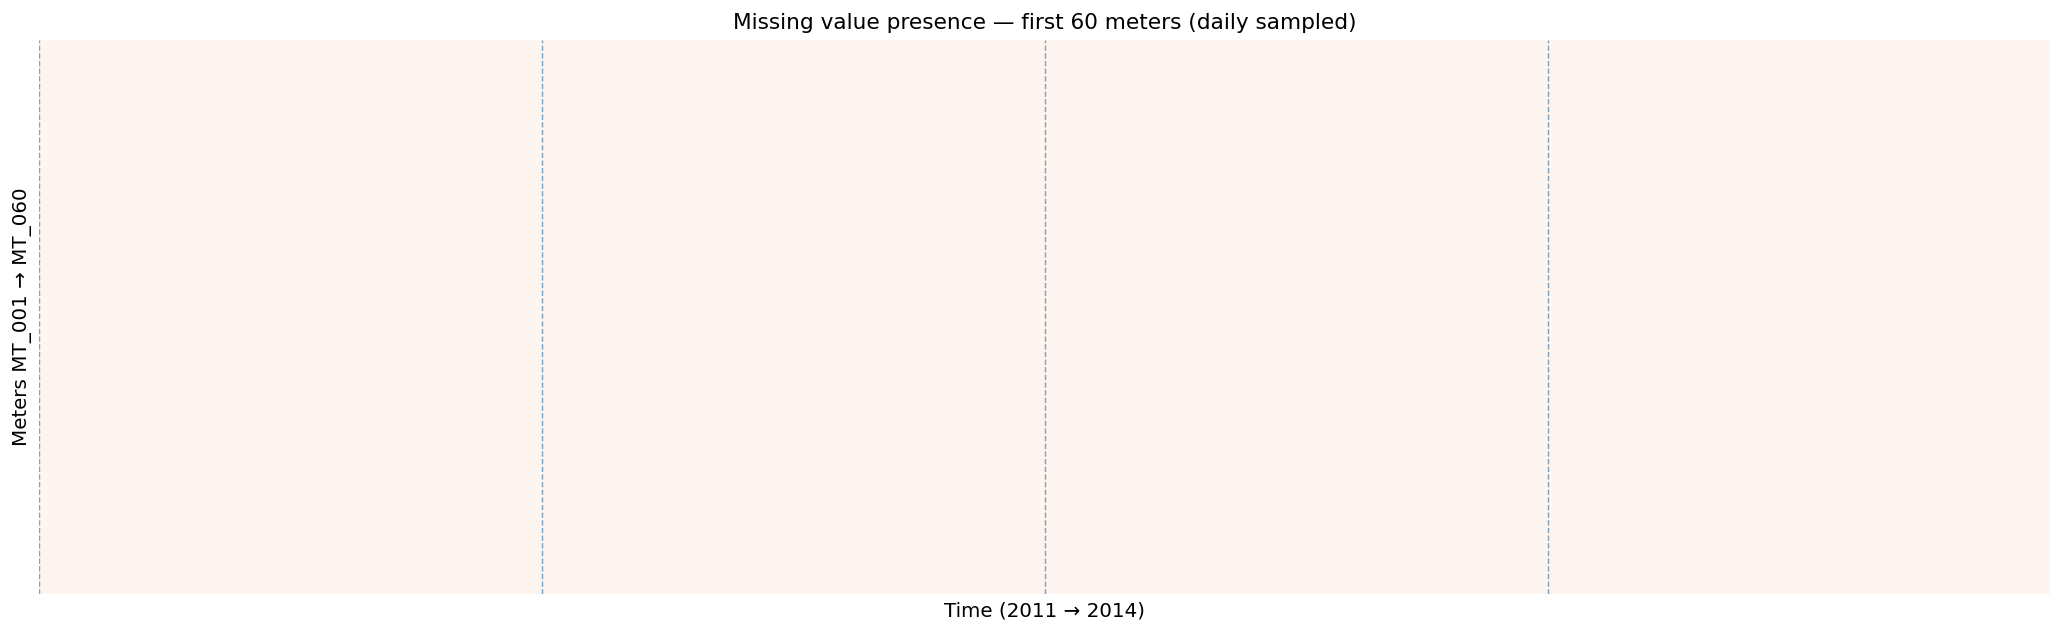

Saved: missing_heatmap.png


In [ ]:
# ── NaN heatmap (sampled for visibility) ─────────────────────────────────────
# Sample every 96 rows (= 1 per day) and first 60 meters for readability
nan_mask = df.isna().iloc[::96, :60]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    nan_mask.T,
    cmap='Reds',
    cbar=False,
    xticklabels=False,
    yticklabels=False,
    ax=ax
)
ax.set_title("Missing value presence — first 60 meters (daily sampled)", fontsize=12)
ax.set_xlabel("Time (2011 → 2014)")
ax.set_ylabel("Meters MT_001 → MT_060")

# Mark year boundaries
year_ticks = [i for i, ts in enumerate(nan_mask.index) if ts.month == 1 and ts.day == 1]
for yt in year_ticks:
    ax.axvline(yt, color='steelblue', linewidth=0.8, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("missing_heatmap.png", dpi=130)
plt.show()
print("Saved: missing_heatmap.png")

Valid meters (≥365 days active): 163 / 370


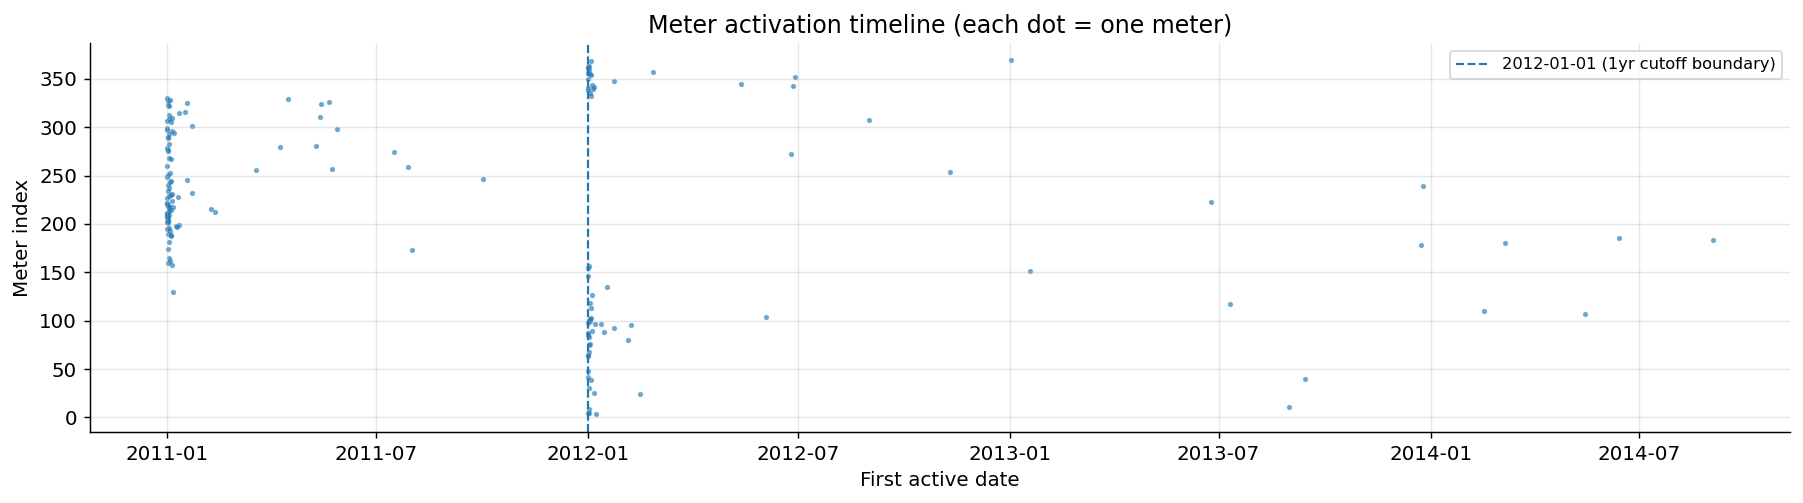

In [ ]:

df_numeric = df.apply(pd.to_numeric, errors='coerce')

# ── First non-zero timestamp per meter ───────────────────────────────────────
def first_active(series):
    nonzero = series[series > 0]
    return nonzero.index[0] if len(nonzero) > 0 else pd.NaT

# Apply on cleaned data
activity_start = df_numeric.apply(first_active)

# Ensure index is datetime
df_numeric.index = pd.to_datetime(df_numeric.index)

activity_days  = (df_numeric.index.max() - activity_start).dt.days

# Keep meters active for at least 365 days
valid_meters = activity_days[activity_days >= 365].index.tolist()
print(f"Valid meters (≥365 days active): {len(valid_meters)} / {len(df_numeric.columns)}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

ax.scatter(activity_start, range(len(activity_start)),
           s=4, alpha=0.5)

ax.set_xlabel("First active date")
ax.set_ylabel("Meter index")
ax.set_title("Meter activation timeline (each dot = one meter)")

ax.axvline(pd.Timestamp('2012-01-01'),
           linestyle='--',
           linewidth=1.2,
           label='2012-01-01 (1yr cutoff boundary)')

ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("meter_activity_chart.png", dpi=130)
plt.show()

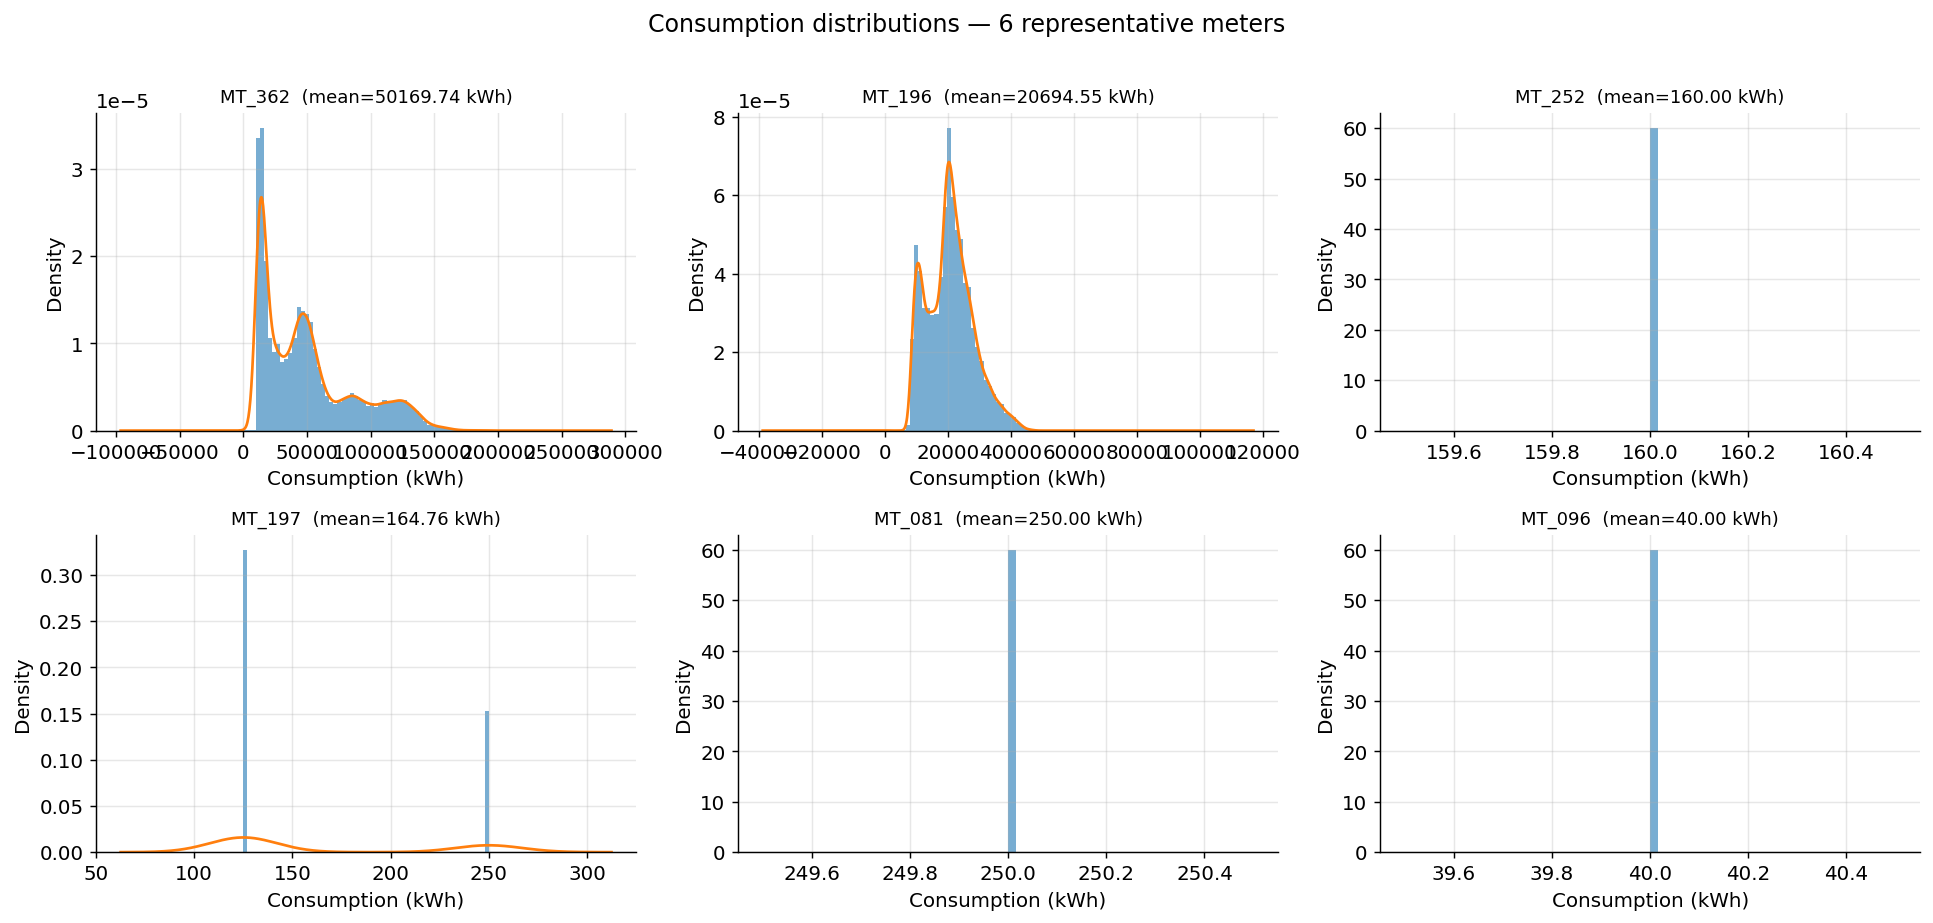

In [ ]:

# ── Pick 6 representative meters ────────────────────────────────────────────
mean_consumption = df_numeric[valid_meters].mean().sort_values(ascending=False)

sample_meters = (
    mean_consumption.iloc[:2].index.tolist() +
    mean_consumption.iloc[len(mean_consumption)//2 - 1 :
                          len(mean_consumption)//2 + 1].index.tolist() +
    mean_consumption.iloc[-2:].index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, meter in enumerate(sample_meters):
    data = df_numeric[meter].dropna()
    data = data[data > 0]

    axes[i].hist(data, bins=60, density=True, alpha=0.6)

    # ✅ SAFE KDE condition
    if len(data) > 10 and data.nunique() > 1:
        data.plot.kde(ax=axes[i], linewidth=1.5)

    axes[i].set_title(f"{meter}  (mean={data.mean():.2f} kWh)", fontsize=10)
    axes[i].set_xlabel("Consumption (kWh)")
    axes[i].set_ylabel("Density")

plt.suptitle("Consumption distributions — 6 representative meters", y=1.01)
plt.tight_layout()
plt.savefig("distributions.png", dpi=130)
plt.show()

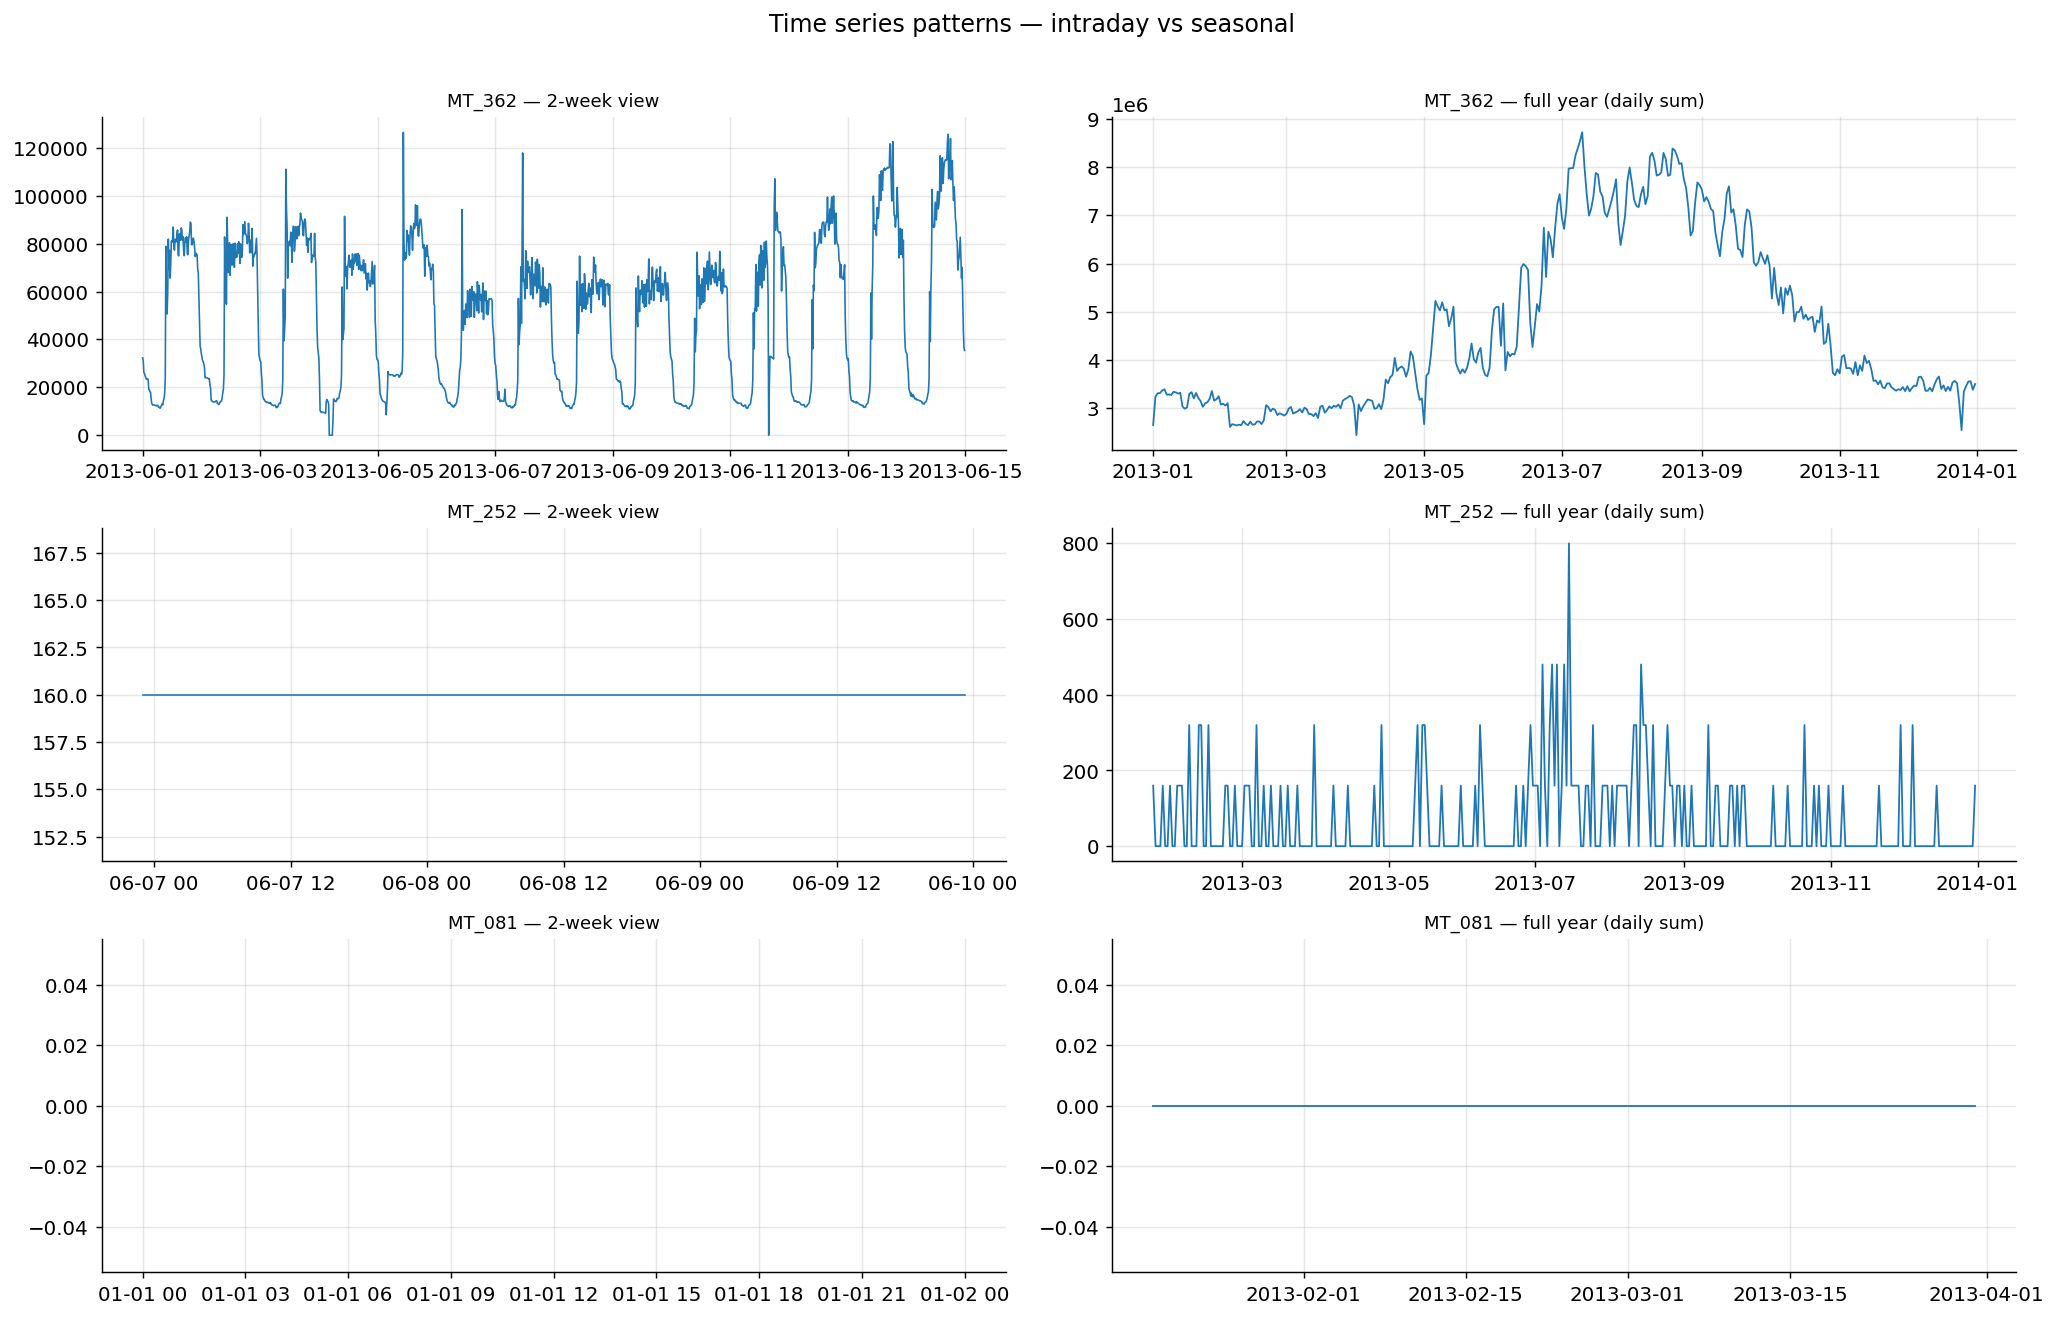

In [ ]:

# ── Select 3 meters for visual inspection ────────────────────────────────────
plot_meters = [sample_meters[0], sample_meters[2], sample_meters[4]]

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, meter in enumerate(plot_meters):
    series = df_numeric[meter].dropna()

    # 2-week window (intraday cycles)
    window_2w = series['2013-06-01':'2013-06-14']
    axes[i, 0].plot(window_2w.index, window_2w.values,
                    linewidth=0.9)
    axes[i, 0].set_title(f"{meter} — 2-week view", fontsize=10)
    axes[i, 0].set_xlabel("")

    # 12-month window (seasonal patterns)
    window_12m = series['2013-01-01':'2013-12-31'].resample('D').sum()
    axes[i, 1].plot(window_12m.index, window_12m.values,
                    linewidth=1.0)
    axes[i, 1].set_title(f"{meter} — full year (daily sum)", fontsize=10)

plt.suptitle("Time series patterns — intraday vs seasonal", y=1.01)
plt.tight_layout()
plt.savefig("timeseries_sample.png", dpi=130)
plt.show()

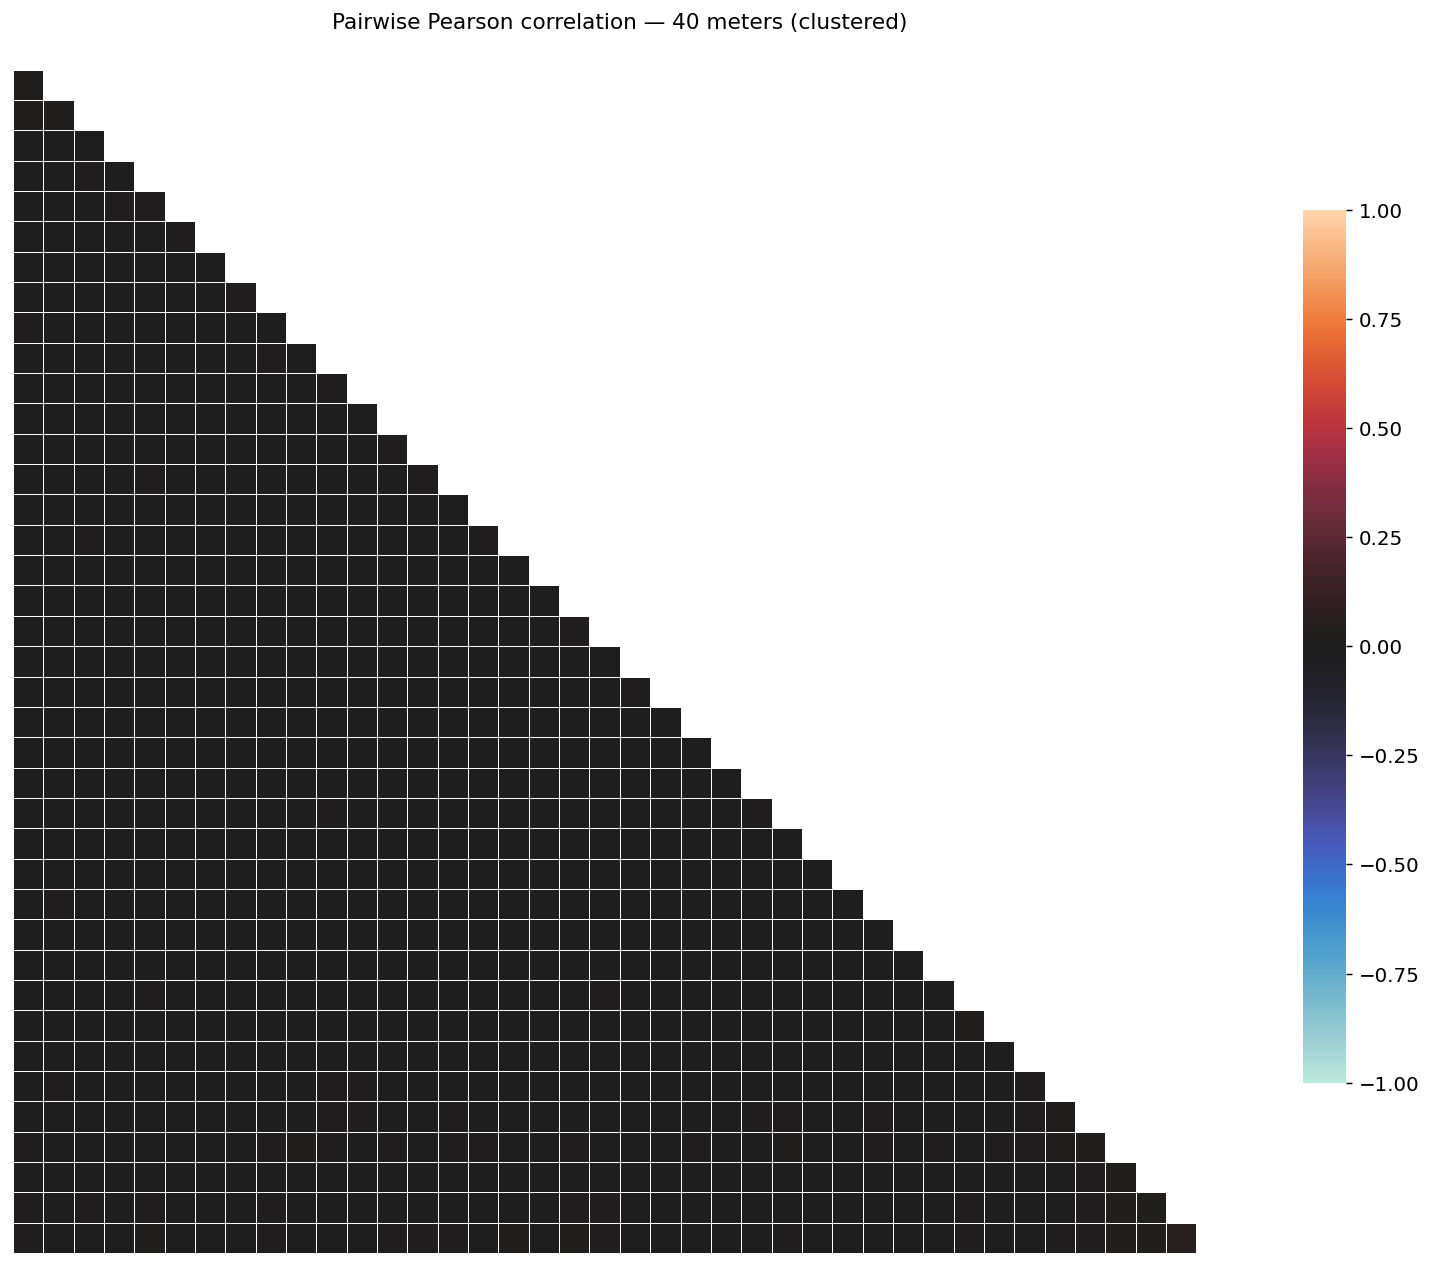

Highly correlated pairs (|r|>0.8): 0


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Ensure numeric + clean data
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Optional but recommended: fill missing values for correlation
df_filled = df_numeric.fillna(0)

# ── Pearson correlation on 40 random valid meters ────────────────────────────
np.random.seed(SEED)
corr_meters = np.random.choice(valid_meters, size=40, replace=False)

corr_matrix = df_filled[corr_meters].corr()

# Replace NaNs (can still occur if constant series)
corr_matrix = corr_matrix.fillna(0)

# ── Hierarchical clustering ──────────────────────────────────────────────────
distance_matrix = 1 - corr_matrix.abs()

# squareform requires zero diagonal and symmetric matrix
np.fill_diagonal(distance_matrix.values, 0)

linkage_matrix = linkage(squareform(distance_matrix), method='ward')
order = dendrogram(linkage_matrix, no_plot=True)['leaves']

corr_ordered = corr_matrix.iloc[order, order]

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_ordered, dtype=bool))

sns.heatmap(
    corr_ordered,
    mask=mask,
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.7},
    xticklabels=False,
    yticklabels=False,
    ax=ax
)

ax.set_title("Pairwise Pearson correlation — 40 meters (clustered)", fontsize=12)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=130)
plt.show()

# ── Print clustering insight ──────────────────────────────────────────────────
high_corr = (corr_matrix.abs() > 0.8).sum().sum() - len(corr_matrix)
print(f"Highly correlated pairs (|r|>0.8): {high_corr // 2}")

most of the values are zero so now for the dataset I want to train for different range in dataset ?